# Partial dependence plot
We have seen SHAP technique to get global and local explanations about how a model behaves when is performing a prediction. Also we know that LIME is like a lightweight version of SHAP to get faster model explanations but works just for local cases (single instances), even is known that LIME outcomes depends on a simple model, so are less accurate than SHAP explains.  
Partial dependecy plots are a simple but powerful method to learn about how our model uses one or two features to produce its outcomes. Calculating partial dependece measure, tells us how value changes on certains variable affects model output.

## How does it works?
Begins from the assumption of every variable in our dataset (excepting the target field) is independent to others.

### Single feature case
Takes the other features as constants and varies the selected feature, then obtains the outcomes of those inputs and averages a dependence score.

### Two features case
As the single variable case, selected variables values are variated and averaged to calculate dependency scores. Lefting fields are taken as constant values.

## Procedure
1. Train a ML model.
2. Select the desired feature(s) to be analysed.
3. Specify categorical fields (if exists).
4. Specify target field (on multiclass or multi-output scenarios).
5. Plot dependence scores.

**Notes:** In classification, the output must be the predicted probability (from `predict_proba` method) or score calculated from `decision_function` method. For regression, model outcome is enough.

In [1]:
from pandas import read_csv
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

data = read_csv("/kaggle/input/datasets/jsonali2003/mobile-price-prediction-dataset/Mobile Price Prediction Datatset.csv")

data = data.drop(columns=["Unnamed: 0"])
COL_MAPPER = {"Brand me": "brand", "Ratings": "user_ratings", "RAM": "ram", 
              "ROM": "storage_size", "Mobile_Size": "display_size_inches", "Primary_Cam": "main_camera_px", "Selfi_Cam": "selfie_camera_px",
              "Battery_Power": "battery", "Price": "price"}
renamed_data = data.rename(columns=COL_MAPPER)

NUMS = ["user_ratings","ram", "storage_size", "display_size_inches", "main_camera_px", "selfie_camera_px", "battery"]
CATS = ["brand"]
FEATURES = NUMS + CATS
TAG = "price"

x_train, x_test, y_train, y_test = train_test_split(renamed_data[FEATURES], renamed_data[TAG], train_size=0.8, random_state=123)

NUM_TRANSFORMER = Pipeline([
    ("imputer", KNNImputer()),
    ("scaler", StandardScaler())
])

CAT_TRANSFORMER = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

TRANSFORMER = ColumnTransformer([
    ("num", NUM_TRANSFORMER, NUMS),
    ("cat", CAT_TRANSFORMER, CATS)
])

X_train = TRANSFORMER.fit_transform(x_train)
X_test = TRANSFORMER.transform(x_test)

# Model definition
MODEL = SVR(kernel="sigmoid", C=100)
MODEL.fit(X_train, y_train)
y_pred = MODEL.predict(X_test)

squared_error = mean_squared_error(y_test, y_pred)
absolute_error = mean_absolute_error(y_test, y_pred)
print(f"Mean squared error: {squared_error:2f}")
print(f"Mean absolute error: {absolute_error:2f}")

Mean squared error: 6344077950.986364
Mean absolute error: 22726.450409


So, error measures shows that our model outcomes are so far from real values. As we can see in the plot, it looks like our model tries to fit its outputs to real values. On small prices the result looks fine, having small diffs with real values but being harder to predict expensive phones.

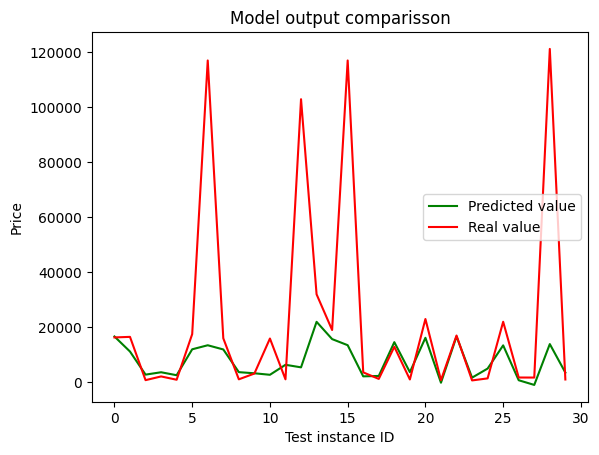

In [2]:
import matplotlib.pyplot as plt

y_Test = y_test.reset_index().drop(columns=["index"])

IDS = list(y_Test.index)

plt.plot(IDS[:30], y_pred[:30], color="green", label="Predicted value")
plt.plot(IDS[:30], y_test[:30], color="red", label="Real value")

plt.title("Model output comparisson")
plt.xlabel("Test instance ID")
plt.ylabel("Price")
plt.legend()
plt.show()

Inspecting the dependence plot of "user_ratings" variable, we see a linear trend, so the model thinks that a model with high ratings is expensive. That's not necessarily true in every case but we got a big insight with a simple technique. "Ram" variable also looks like a line but its slope is lower than "user_rating" feature and we watch that many values shares the same output.

[Text(-3.0, 0, '-2'),
 Text(-2.0, 0, '1'),
 Text(-1.0, 0, '3'),
 Text(0.0, 0, '6'),
 Text(1.0, 0, '9'),
 Text(2.0, 0, '11'),
 Text(3.0, 0, '14')]

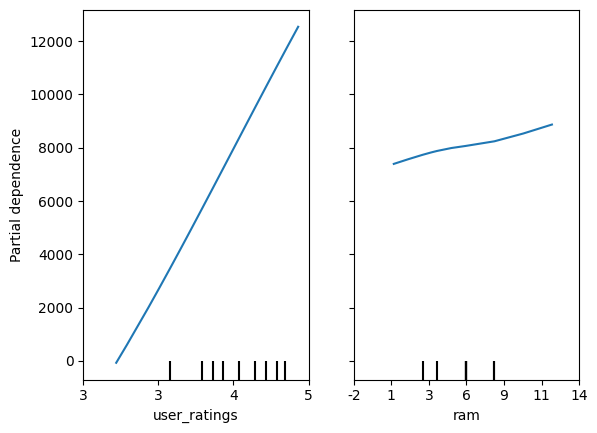

In [3]:
from sklearn.inspection import PartialDependenceDisplay

scaler = TRANSFORMER.named_transformers_["num"].named_steps["scaler"]

x_test_array = X_test.toarray()
COLS = list(x_test.columns)

ax = PartialDependenceDisplay.from_estimator(MODEL, x_test_array, (0,1), categorical_features=[7], feature_names=COLS)


# Ticks user_ratings
ticks_user = ax.axes_[0, 0].get_xticks()
ticks_user_original = (
    ticks_user * scaler.scale_[0]
    + scaler.mean_[0]
)

ax.axes_[0, 0].set_xticks(ticks_user)
ax.axes_[0, 0].set_xticklabels(
    [f"{x:.0f}" for x in ticks_user_original]
)


# Ticks RAM
ticks_ram = ax.axes_[0, 1].get_xticks()
ticks_ram_original = (
    ticks_ram * scaler.scale_[1]
    + scaler.mean_[1]
)
ax.axes_[0, 1].set_xticks(ticks_ram)
ax.axes_[0, 1].set_xticklabels(
    [f"{x:.0f}" for x in ticks_ram_original]
)

The following chart, shows that there is not a significant interaction among "user_ratings" and "ram" features. Areas are almost the same and we can see that the price increases only when "user_ratings" does, "ram" features doesn't has a significant effect on target price.

[Text(0, -3.0, '-2'),
 Text(0, -2.0, '1'),
 Text(0, -1.0, '3'),
 Text(0, 0.0, '6'),
 Text(0, 1.0, '9'),
 Text(0, 2.0, '11'),
 Text(0, 3.0, '14')]

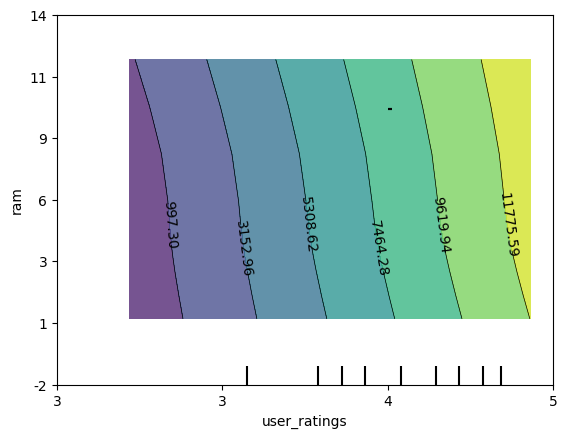

In [4]:
ax_compound = PartialDependenceDisplay.from_estimator(MODEL, x_test_array, [(0,1)], categorical_features=[7], feature_names=COLS)

ax_compound.axes_[0, 0].set_xticks(ticks_user)
ax_compound.axes_[0, 0].set_xticklabels(
    [f"{x:.0f}" for x in ticks_user_original]
)
ax_compound.axes_[0, 0].set_yticks(ticks_ram)
ax_compound.axes_[0, 0].set_yticklabels(
    [f"{x:.0f}" for x in ticks_ram_original]
)

# Individual conditional expectation plot
This is a dependence plot variant, but in this case, just works for a single at once. Key difference is that ICE chart plots each outcome of the dataset for each instance.

[Text(-4.0, 0, '3'), Text(-2.0, 0, '3'), Text(0.0, 0, '4'), Text(2.0, 0, '5')]

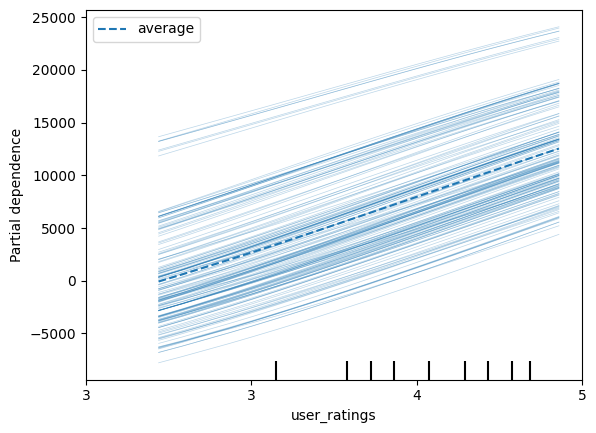

In [5]:
# Plotting PDP and ICEP at once, to just plot ICE change "both" to "individual" on "kind" parameter
ax_ice = PartialDependenceDisplay.from_estimator(MODEL, x_test_array, (0,), categorical_features=[7], feature_names=COLS, kind="both")

ax_ice.axes_[0, 0].set_xticks(ticks_user)
ax_ice.axes_[0, 0].set_xticklabels(
    [f"{x:.0f}" for x in ticks_user_original]
)